# Confounders

[**Simpson's paradox**](https://en.wikipedia.org/wiki/Simpson%27s_paradox) is a phenomenon in probability and statistics in which a trend appears in several groups of data but disappears or reverses when the groups are combined.

This result is often encountered in social-science and medical-science statistics, and is particularly problematic when frequency data are unduly given causal interpretations. The paradox can be resolved when **confounding variables** and causal relations are appropriately addressed in the statistical modeling

## Example: Bill Depth and Length Grouped by Species

In [ ]:
import seaborn as sns

In [ ]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


If you look at the whole dataset, there is a **negative** correlation between `bill_depth` and `bill_length`:

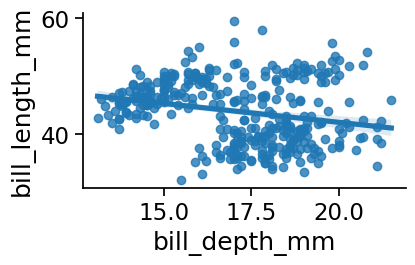

In [ ]:
sns.lmplot(
    data=penguins,
    x="bill_depth_mm", y="bill_length_mm",
    aspect=1.5, height=3
);

When you color-code by `species`, the correlation within each group is actually **positive**:

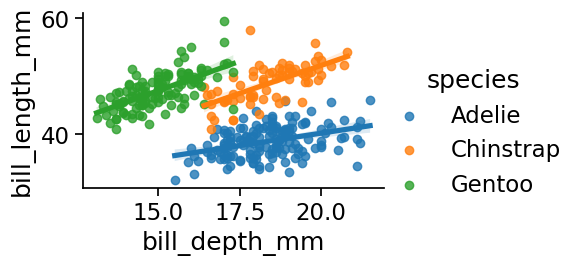

In [ ]:
sns.lmplot(
    data=penguins,
    x="bill_depth_mm", y="bill_length_mm", hue="species",
    aspect=1.5, height=3
);

The presence of confounders helps explain why correlation does not imply causation, and why careful study design and analytical methods are required to distinguish causal effects from spurious associations.

## Non-examples

### Non-example 1: Body Mass and Flipper Length

If you plot Body Mass against Flipper Length, you see a strong, **positive correlation** in the general population. As penguins get larger, their flippers get longer.

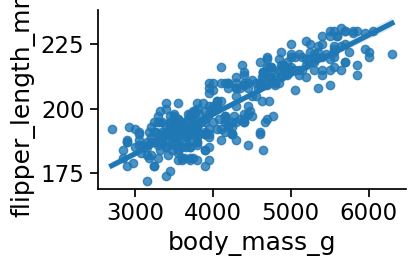

In [ ]:
sns.lmplot(
    data=penguins,
    x="body_mass_g", y="flipper_length_mm",
    aspect=1.5, height=3
);

Perhaps `sex` is a confounder? To find out, let's color-code and plot it's regression line:

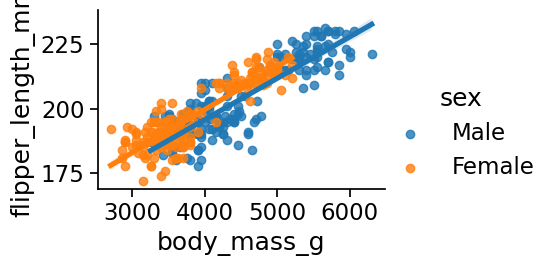

In [ ]:
sns.lmplot(
    data=penguins,
    x="body_mass_g", y="flipper_length_mm", hue="sex",
    aspect=1.5, height=3
);

Observation: correlation is maintained.

### Non-example 2: Species and Flipper Length

Maybe `species` is a confounder?

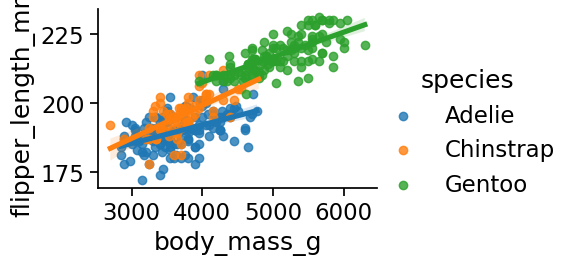

In [ ]:
sns.lmplot(
    data=penguins,
    x="body_mass_g", y="flipper_length_mm", hue="species",
    aspect=1.5, height=3
);

Observation: correlation is maintained.

As such, we are convinced that the relationship isn't affected by neither `sex` nor `species`.